## Understanding Difference Equations

A **difference equation** is a mathematical formula that calculates the current output signal $y[n]$ based on the current and past input samples, such as $x[n]$, $x[n-1]$, etc.

Instead of thinking of it as a vague or complicated formula, it’s helpful to think of the input signal $x[n]$ like an array in programming languages such as Python, Java, or C/C++. Each index $n$ represents a point in time, and each value in the array is a sound sample taken at that moment.

For example:
- $x[n]$ is the current sample  
- $x[n-1]$ is the previous sample  
- $x[n-2]$ is the sample before that  

Using this idea, a difference equation computes the output $y[n]$ by combining different elements of this “array” through addition, subtraction, and multiplication to produce a new signal.

## How to Make Echoes

The difference equation used to create an echo effect is:

$$
y[n] = x[n] + \frac{1}{2} x[n-D]
$$

where: 
- $x[n]$ is the current sound sample  
- $x[n-D]$ is the sample from $D$ samples ago  
- $\frac{1}{2}$ scales the delayed signal so the echo is quieter and fades over time  

> Note: $D$ represents a delay in **number of samples**, not seconds. The actual time delay depends on the sampling rate. For example, at a sampling rate of 48 kHz, $D = 240{,}000$ corresponds to 5 seconds.

## Echoes in SystemVerilog

### 1. Open echo.sv in Quartus
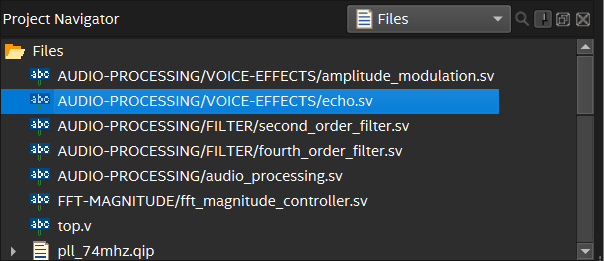

### 2. Create internal signals and registers

To implement an echo effect we need: 
- a index variable that tracks our position in the array 
- an array to store previous audio samples
- a variable to hold the delayed sample, $x[n - D]$

Copy the following signals to your module: 
```systemverilog
logic [$clog2(DELAYED_SAMPLES)-1:0] index;
logic signed [SAMPLE_WIDTH-1:0] prev_samples [0:DELAYED_SAMPLES-1]; // array of previous samples
logic signed [SAMPLE_WIDTH-1:0] delayed_sample;
```

> Note: `$clog2(N)` returns the minimum number of bits required to represent values up to `N`.

### 3. Write the Sequential Logic

#### 3.1 Reset the index to 0
We reset the index and output so the system starts in a known state.  Otherwise, it could be random which could lead to incorrect calculations.

In the `always_ff @(posedge clk)` block, find:

```systemverilog
if (reset) begin
    // Reset logic
end
```

Add the following inside this block:
```systemverilog
index <= 0;
data_out <= 0;
```
#### 3.2 Compute $x[n] + \frac{1}{2}x[n-D]$

In the `always_ff @(posedge clk)` block, find:

```systemverilog
else if (data_valid) begin
    // Echo effect logic

end
```

This is where we will be writing all the logic to create our echo effect. 

First, we need to read the delayed sample from the array by copying the following: 
```systemverilog
delayed_sample <= prev_samples[index];
```

**Your Turn:**

Write to `data_out` (which is $y[n]$) using:
- the current input $x[n]$: `data_in`
- the delayed sample you just read $x[n - D]$: `delayed_sample`

> Hint: In Verilog, `>>> 1` performs an arithmetic right shift ($\div$ 2).

#### 3.3 Store the sample

After computing the output, we store it in the array. 

**Your Turn:**

Store the computed output back into `prev_samples[index]` using the same expression as data_out.

We do this so $x[n-D]$ includes past outputs, creating feedback that produces multiple echoes that fade over time.

> Note: We cannot do `prev_samples[index] <= data_out` because `data_out` has not been updated yet in the same clock cycle which can lead to incorrect behavior

#### 3.4 Update the index 

We need to wrap the index back to the start once it's at `D` samples. 

Copy the following into your module: 
```systemverilog
if (index == DELAYED_SAMPLES - 1) index <= 0;
else index <= index + 1;
```

### 4. Result

You should now hear your own voice echoed back at you as you speak into the mic.

## Next Steps

Try experimenting with your echo effect: 

#### 1. Change the decay
Adjust how quickly the echo fades by changing the shift amount (e.g. `>>> 2`)
> Note: You can only scale by powers of 2 using shifts. Because `>>> 1` divides by $2^1$, `>>> 2` divides by $2^2$, and so on.

#### 2. Change the delay

Notice the parameter at the top of `echo.sv`:

```systemverilog
parameter DELAYED_SAMPLES = 9000;
```

This controls how long the delay is. 

Try increasing or decreasing `DELAYED_SAMPLES` to change how long it takes before you hear the echo.

> Note: The actual delay time is given by 
>
>$\text{time} = \frac{\text{DELAYED\_SAMPLES}}{\text{sampling rate}}$
>
> Our sample rate is **48.1 kHz** and if `DELAYED_SAMPLES` is 9000 then the time between our echoes is:
>
> $\text{time} = \frac{9000}{48100} = 0.187 \text{  seconds}$ 
